In [1]:
import numpy as np
import matplotlib.pyplot as plt

from itertools import chain, combinations

In [2]:

from sian.data import final_save_header
from sian.data import final_save_dataset
from sian.data import final_save_labels

from sian.utils import gettimestamp

base_save_dataset_path = "data/"
datetimestr = gettimestamp()

In [5]:

def traingle_sinewave(X):
    #move to the interval [-1,1]
    #xd = np.fmod(X,2.0)
    xd = (X+1.0) % 2.0 - 1.0
    xd_sign = np.sign(xd)
    xdd = np.abs(xd)
    thingy = (xdd<=0.5)*2*xdd + (xdd>0.5)*(2-2*xdd)
    thingy = xd_sign * thingy
    # plt.scatter(X,xd)
    # plt.show()
    # plt.scatter(X,thingy)
    # plt.show()
    pass
    return thingy


# N = 1000*1000
TRN_N = 1000*1000
TST_N = 10*1000
N = TRN_N + TST_N

# Ds = [10,30,50]
Ds = [10,20,30]
seeds=list(range(5))

# D = 10


MAX_TUPLES_PER_BAND = 300
MAX_TUPLES_PER_BAND = 4  #04/16/2025 @ 6:00pm
MAX_TUPLES_PER_BAND = 1  #04/16/2025 @ 6:20pm
for D in Ds:
    for seed in seeds:
        np.random.seed(seed)
        synth_dataset_id = f"SYNTH_simple_synthwave_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v2_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v3_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v4_D{D}_seed{seed}"
        preproc_owner = None #TODO: check if this is fine
        print(synth_dataset_id)
        save_dataset_path = base_save_dataset_path + synth_dataset_id + "/"


        singles = [(i,) for i in range(D)]
        pairs = list(combinations((range(D)),2))
        triples = list(combinations((range(D)),3))

        singles=singles[:MAX_TUPLES_PER_BAND]
        pairs=pairs[:MAX_TUPLES_PER_BAND]
        triples=triples[:MAX_TUPLES_PER_BAND]

        all_indices = singles + pairs + triples



        # X = (np.random.rand(N,D)*2-1)*np.sqrt(3)
        # X = (np.random.rand(N,D)*2-1)*np.sqrt(1)
        X = (np.random.rand(N,D)*2-1)*np.sqrt(4)


        beta_dict = {}
        beta_power_bands = {}
        for K in range(3):
            beta_power_bands[K+1] = 0.0
        for tup in all_indices:
            beta_tt = np.random.randn()
            beta_dict[tup] = beta_tt
            beta_power_bands[len(tup)] += beta_tt**2

        full_y = 0.0
        for tup in all_indices:
            # final_beta_tt = beta_dict[tup] / beta_power_bands[len(tup)] * 2.0 / 3.
            # final_beta_tt = beta_dict[tup] / np.sqrt(beta_power_bands[len(tup)]) * np.sqrt(2.0) / np.sqrt(3.)
            
            final_beta_tt = beta_dict[tup] / np.sqrt(beta_power_bands[len(tup)]) * np.sqrt(3.0) / np.sqrt(3.) #04/16/2025 @ 7:00pm

            preX = 0.0
            for i in tup:
                preX += X[:,i]
            ###preY = np.sin(np.pi*preX)
            preY = traingle_sinewave(preX) #starting with v4

            full_y += final_beta_tt * preY
        print('full_y','var',np.var(full_y))
        
        readable_labels = {}
        full_readable_labels = {}
        startdim = 0
#         for d in range(D):
        for d in range(-1,D):
            full_info_d = {
                "label" : "X"+str(d+1),
                "startdim" : d,
                "numdims" : 1,
                "encoding" : "cts.raw",
            }
            if d==-1:
                full_info_d = {
                    "label" : "Y",
                    "startdim" : d,
                    "numdims" : 1,
                    "encoding" : "cts.raw",
                }
            readable_labels[d] = full_info_d["label"]
            full_readable_labels[d] = full_info_d
        full_readable_labels["task_type"] = "regression"
        full_readable_labels["D0"] = D
        full_readable_labels["D"] = D
        
        
        fake_header_dict = {
            "Preprocessed Datetime" : datetimestr, 
            "dataset_id" : synth_dataset_id,
            "preproc_owner" : preproc_owner,

            #"load_dataset_path" : load_dataset_path,
            #"save_dataset_path" : save_dataset_path,
        }

        trainval_portion, is_test_split_shuffled, shuffle_test_split_seed = None, False, None
        if trainval_portion is None:
            trainval_portion = 0.80
            trainval_portion = TRN_N/N
            assert int(trainval_portion*N)==TRN_N
        fake_header_dict["is_test_split_shuffled"]  = is_test_split_shuffled
        fake_header_dict["shuffle_test_split_seed"] = shuffle_test_split_seed
        fake_header_dict["trainval_portion"]        = trainval_portion
        
        fake_header_dict["datagen_seed"] = seed

        #######label_stuff = (full_readable_labels, datatype_labels, full_readable_labels)
        label_stuff = (readable_labels, full_readable_labels)    
        label_dict = {
            "readable_labels" : label_stuff[0],
            "full_readable_labels" : label_stuff[1],
        }

        if True:
            fullX=X; fullY=full_y;
            final_save_header(save_dataset_path, fake_header_dict)
            trnvalX,trnvalY,tstX,tstY = final_save_dataset(save_dataset_path, fullX, fullY, 
                                                            trainval_portion, is_test_split_shuffled, shuffle_test_split_seed)

            ''' asdf asdf asdf '''
            ### #### #### #### ###
#             final_save_labels(save_dataset_path, *label_stuff)
            final_save_labels(save_dataset_path, label_dict)

SYNTH_simple_synthwave_v4_D10_seed0
full_y var 1.0002697819909803
SYNTH_simple_synthwave_v4_D10_seed1
full_y var 1.0029551152391862
SYNTH_simple_synthwave_v4_D10_seed2
full_y var 1.0005918764663673
SYNTH_simple_synthwave_v4_D10_seed3
full_y var 1.0003689178068758
SYNTH_simple_synthwave_v4_D10_seed4
full_y var 0.9989274920774589
SYNTH_simple_synthwave_v4_D20_seed0
full_y var 0.9983199305788023
SYNTH_simple_synthwave_v4_D20_seed1
full_y var 0.9981579164402713
SYNTH_simple_synthwave_v4_D20_seed2
full_y var 0.999912023750879
SYNTH_simple_synthwave_v4_D20_seed3
full_y var 0.9997549490781723
SYNTH_simple_synthwave_v4_D20_seed4
full_y var 1.0007149913345443
SYNTH_simple_synthwave_v4_D30_seed0
full_y var 1.0012843193859404
SYNTH_simple_synthwave_v4_D30_seed1
full_y var 1.0011427000928483
SYNTH_simple_synthwave_v4_D30_seed2
full_y var 1.002289625212616
SYNTH_simple_synthwave_v4_D30_seed3
full_y var 1.0005408409335415
SYNTH_simple_synthwave_v4_D30_seed4
full_y var 1.0010455799085092


SYNTH_simple_synthwave_v4_D10_seed0


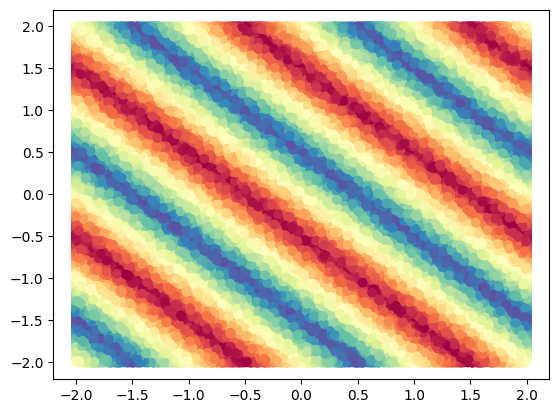

full_y var 1.0002697819909803
SYNTH_simple_synthwave_v4_D10_seed1


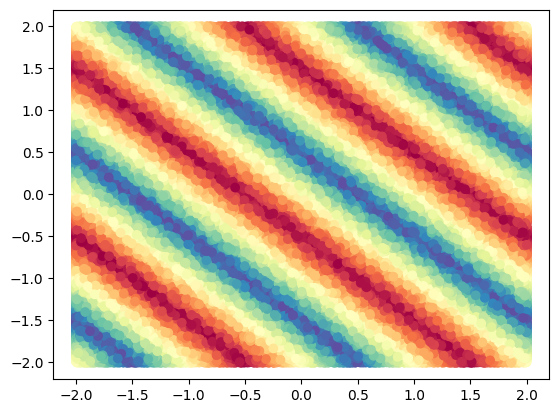

full_y var 1.0029551152391862
SYNTH_simple_synthwave_v4_D10_seed2


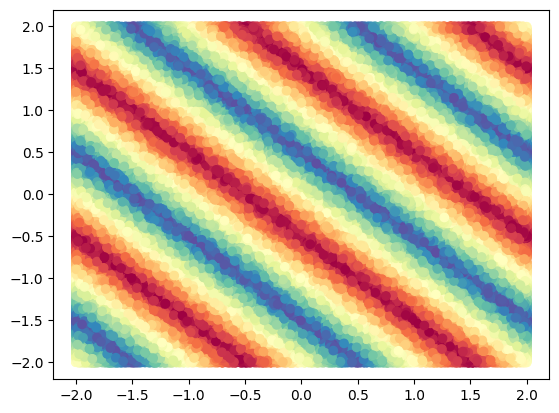

full_y var 1.0005918764663673
SYNTH_simple_synthwave_v4_D10_seed3


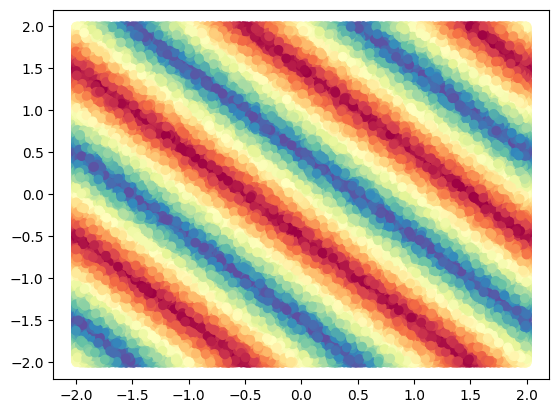

full_y var 1.0003689178068758
SYNTH_simple_synthwave_v4_D10_seed4


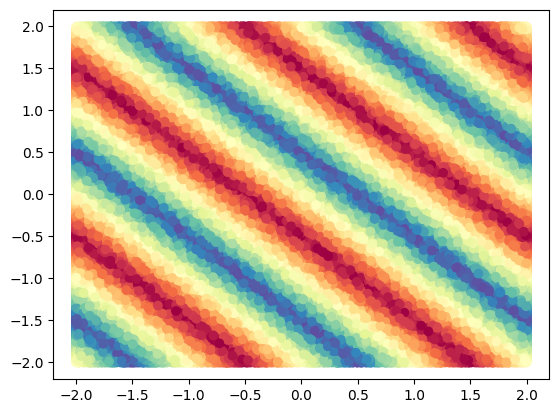

full_y var 0.9989274920774589
SYNTH_simple_synthwave_v4_D20_seed0


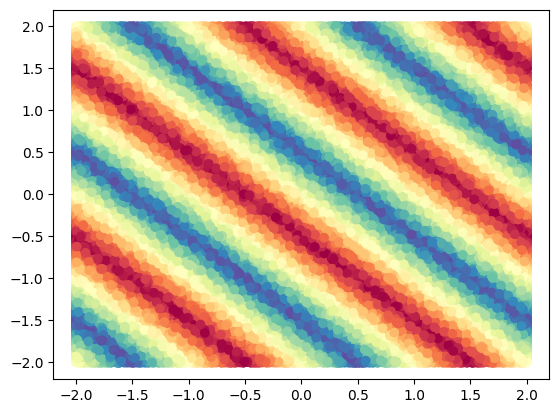

full_y var 0.9983199305788023
SYNTH_simple_synthwave_v4_D20_seed1


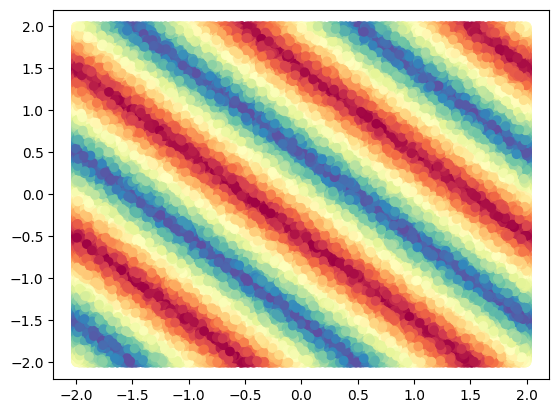

full_y var 0.9981579164402713
SYNTH_simple_synthwave_v4_D20_seed2


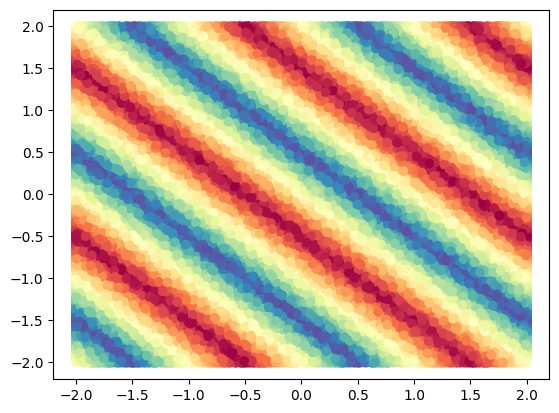

full_y var 0.999912023750879
SYNTH_simple_synthwave_v4_D20_seed3


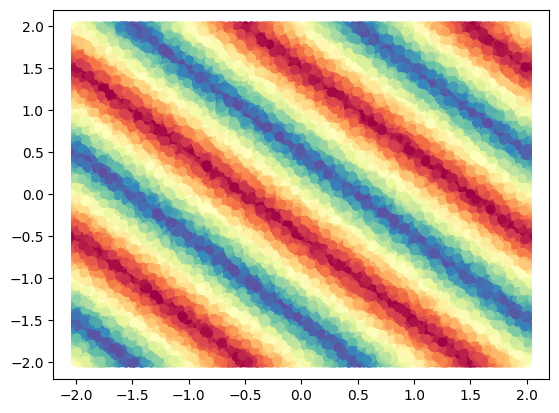

full_y var 0.9997549490781723
SYNTH_simple_synthwave_v4_D20_seed4


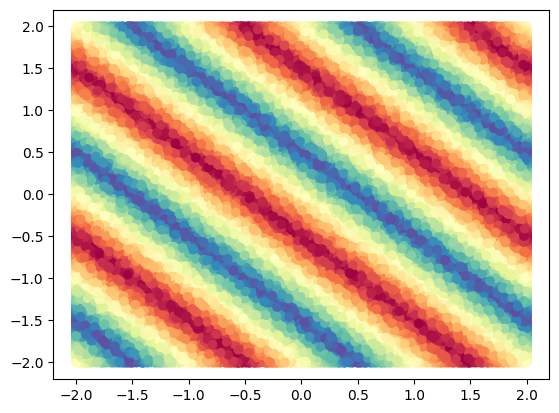

full_y var 1.0007149913345443
SYNTH_simple_synthwave_v4_D30_seed0


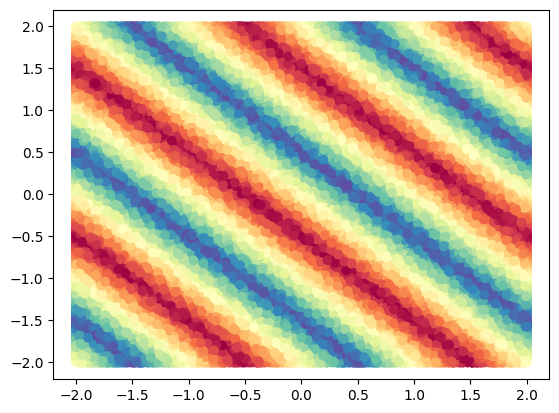

full_y var 1.0012843193859404
SYNTH_simple_synthwave_v4_D30_seed1


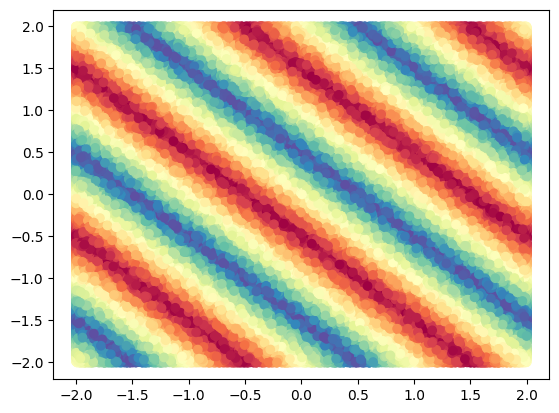

full_y var 1.0011427000928483
SYNTH_simple_synthwave_v4_D30_seed2


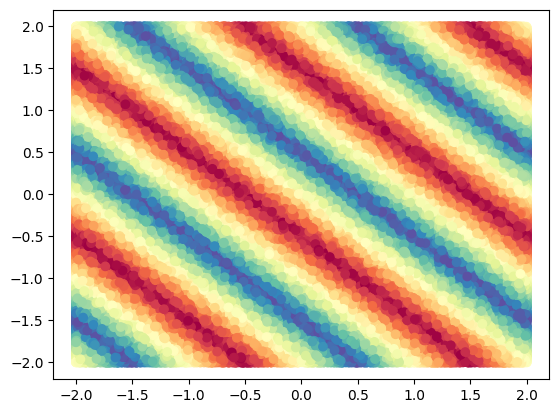

full_y var 1.002289625212616
SYNTH_simple_synthwave_v4_D30_seed3


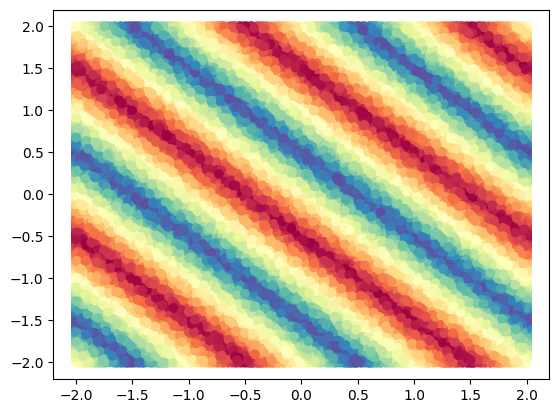

full_y var 1.0005408409335415
SYNTH_simple_synthwave_v4_D30_seed4


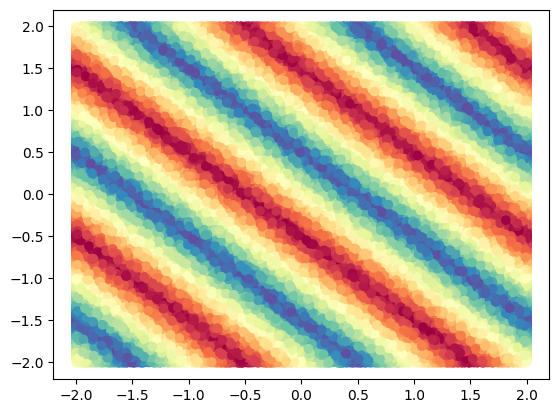

full_y var 1.0010455799085092


In [6]:

def traingle_sinewave(X):
    #move to the interval [-1,1]
    #xd = np.fmod(X,2.0)
    xd = (X+1.0) % 2.0 - 1.0
    xd_sign = np.sign(xd)
    xdd = np.abs(xd)
    thingy = (xdd<=0.5)*2*xdd + (xdd>0.5)*(2-2*xdd)
    thingy = xd_sign * thingy
    # plt.scatter(X,xd)
    # plt.show()
    # plt.scatter(X,thingy)
    # plt.show()
    pass
    return thingy


# N = 1000*1000
TRN_N = 1000*1000
TST_N = 10*1000
N = TRN_N + TST_N

# Ds = [10,30,50]
Ds = [10,20,30]
seeds=list(range(5))

# D = 10


MAX_TUPLES_PER_BAND = 300
MAX_TUPLES_PER_BAND = 4  #04/16/2025 @ 6:00pm
MAX_TUPLES_PER_BAND = 1  #04/16/2025 @ 6:20pm
for D in Ds:
    for seed in seeds:
        np.random.seed(seed)
        synth_dataset_id = f"SYNTH_simple_synthwave_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v2_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v3_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v4_D{D}_seed{seed}"
        preproc_owner = None #TODO: check if this is fine
        print(synth_dataset_id)
        save_dataset_path = base_save_dataset_path + synth_dataset_id + "/"


        singles = [(i,) for i in range(D)]
        pairs = list(combinations((range(D)),2))
        triples = list(combinations((range(D)),3))

        singles=singles[:MAX_TUPLES_PER_BAND]
        pairs=pairs[:MAX_TUPLES_PER_BAND]
        triples=triples[:MAX_TUPLES_PER_BAND]

        all_indices = singles + pairs + triples



        # X = (np.random.rand(N,D)*2-1)*np.sqrt(3)
        # X = (np.random.rand(N,D)*2-1)*np.sqrt(1)
        X = (np.random.rand(N,D)*2-1)*np.sqrt(4)


        beta_dict = {}
        beta_power_bands = {}
        for K in range(3):
            beta_power_bands[K+1] = 0.0
        for tup in all_indices:
            beta_tt = np.random.randn()
            beta_dict[tup] = beta_tt
            beta_power_bands[len(tup)] += beta_tt**2

        full_y = 0.0
        for tup in all_indices:
            # final_beta_tt = beta_dict[tup] / beta_power_bands[len(tup)] * 2.0 / 3.
            # final_beta_tt = beta_dict[tup] / np.sqrt(beta_power_bands[len(tup)]) * np.sqrt(2.0) / np.sqrt(3.)
            
            final_beta_tt = beta_dict[tup] / np.sqrt(beta_power_bands[len(tup)]) * np.sqrt(3.0) / np.sqrt(3.) #04/16/2025 @ 7:00pm

            preX = 0.0
            for i in tup:
                preX += X[:,i]
            ###preY = np.sin(np.pi*preX)
            preY = traingle_sinewave(preX) #starting with v4

            if len(tup)==2:
                plt.scatter(X[:,tup[0]],X[:,tup[1]],c=preY,cmap='Spectral')
                plt.show()

            full_y += final_beta_tt * preY
        print('full_y','var',np.var(full_y))
        